In [1]:
import networkx as nx
import pandas as pd # version 2.3.1 installed cocurrenlty with skmob
import geopandas as gpd #1.0.1
import numpy as np # 2.2.6
import shapely   # 2.0.7 , measure importance of features through SHAP values
import os
import skmob
import dropbox
import os
from dotenv import load_dotenv 
from dropbox import DropboxOAuth2FlowNoRedirect

In [2]:
def authorize():
    load_dotenv()
    APP_KEY = os.environ.get("DROPBOX_APP_KEY")
    APP_SECRET = os.environ.get("DROPBOX_APP_SECRET")

    auth_flow = DropboxOAuth2FlowNoRedirect(APP_KEY,
                                            use_pkce = True,
                                            consumer_secret=APP_SECRET,
                                            token_access_type='offline',
                                            scope=['files.content.read'])

    authorize_url = auth_flow.start()
    print("1. Go to: " + authorize_url)
    print("2. Click \"Allow\" (you might have to log in first).")
    print("3. Copy the authorization code.")
    auth_code = input("Enter the authorization code here: ").strip()

    try:
        oauth_result = auth_flow.finish(auth_code)
        assert oauth_result.scope == 'files.content.read files.metadata.read'
    except Exception as e:
        print('Error: %s' % (e,))
        print(oauth_result.scope)
        exit(1)

    with dropbox.Dropbox(oauth2_access_token=oauth_result.access_token,
                        oauth2_access_token_expiration=oauth_result.expires_at,
                        oauth2_refresh_token=oauth_result.refresh_token,
                        app_key=APP_KEY,
                        app_secret=APP_SECRET) as dbx:        
        print("Successfully set up client!")
        return dbx

In [3]:
dbx = authorize()

1. Go to: https://www.dropbox.com/oauth2/authorize?response_type=code&client_id=vbt4c90yghbwqpt&token_access_type=offline&code_challenge=WGbvfh7cRHXZoSfLK4K2I_PV3svtYktTw2VcGAhL_yQ&code_challenge_method=S256&scope=files.content.read
2. Click "Allow" (you might have to log in first).
3. Copy the authorization code.
Successfully set up client!


In [4]:
from io import BytesIO

In [ ]:
def load_data(dbx: dropbox.Dropbox, data_folder_path:str) -> tuple:
    """
    Returns:
        A tuple containing:
        - A dictionary with keys being each state code and values being the original datasets for that state with columns
        "Otract", "Dtract", "EST"
        - Ditto, but the dataset contains the columns "Id", "Jobs", "Pop" 
    """
    datasets = {}
    data_folder = dbx.files_list_folder(data_folder_path)
    for file in data_folder.entries:
        # file.name.split("_") creates list of items split from the filename -> [-1] access last item -> .split(".") splits last item by "."-> [0] accesses the first item which is the state code
        state_code = file.name.split("_")[-1].split(".")[0]
        file_path = os.path.join(data_folder_path, file.name)
        metaData, data = dbx.files_download(file_path)
        df = pd.read_csv(BytesIO(data.content))
        df['Otract'] = df['Otract'].astype(str)
        df['Dtract'] = df['Dtract'].astype(str)
        # Add the DataFrame to the container with the state code as the label
        datasets[state_code] = df
    dbx.close()

    dsets_grouped = {}
    for state_code, df in datasets.items():
        grouped = pd.DataFrame(set(df['Otract'].unique()).union(set(df['Dtract'].unique())), 
                        columns = ["Id"])
        jobs = df.groupby('Dtract')['EST'].sum()
        grouped['Jobs'] = grouped['Id'].map(jobs)
        grouped['Jobs'] = grouped['Jobs'].fillna(0).astype(str) # SWITCHED FROM INT, DOES IT STILL WORK?
        pop = df.groupby('Otract')['EST'].sum()
        grouped['Pop'] = grouped['Id'].map(pop)
        grouped['Pop'] = grouped['Pop'].fillna(0).astype(str)
        dsets_grouped[state_code] = grouped
    assert not dsets_grouped['FL'].isna().values.any() and not datasets['FL'].isna().values.any()
    return datasets, dsets_grouped

In [6]:
datasets, dsets_grouped = load_data(dbx, "/Mobility Prediction/data/ctpp/2017-2021")

In [7]:
dsets_grouped['FL'].head()

,Id,Jobs,Pop
0,36071014400,25,0
1,12071010305,482,1628
2,12011110402,945,2337
3,12011110403,329,1853
4,12011110404,354,2120


In [8]:
datasets['FL'].head()

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0
2,12001000201,12001000301,20.0
3,12001000201,12001000400,225.0
4,12001000201,12001000500,35.0


In [9]:
grouped = pd.DataFrame(set(datasets['FL']['Otract'].unique()).union(set(datasets['FL']['Dtract'].unique())), 
                        columns = ["Id"])
for id in grouped["Id"]:
    if id not in dsets_grouped['FL']['Id'].values:
        print(id, '\n')

In [11]:
for id in dsets_grouped['FL']['Id']:
    if id not in grouped['Id'].values:
        print(id, '\n')

In [89]:
jobs = datasets['FL'].groupby('Dtract')['EST'].sum()

In [92]:
jobs.head()

Dtract
1003010100     10.0
1003010200     10.0
1003010400    105.0
1003010500    140.0
1003010704     20.0
Name: EST, dtype: float64

In [94]:
jobs.index

Index([ 1003010100,  1003010200,  1003010400,  1003010500,  1003010704,
        1003010708,  1003010710,  1003010904,  1003010908,  1003011000,
       ...
       55133203601, 55133203704, 55133203803, 55133204100, 55139001400,
       55139001700, 55141010400, 55141011100, 56005000300, 56033000400],
      dtype='int64', name='Dtract', length=8253)

In [96]:
count = 0
for id in datasets['FL']['Dtract'].unique():
    if id not in jobs.index:
        count += 1
print(count)

0


In [103]:
grouped = pd.DataFrame(set(datasets['FL']['Otract'].unique()).union(set(datasets['FL']['Dtract'].unique())), 
                        columns = ["Id"])
for id in grouped["Id"]:
    if id not in jobs.index:
        print(id, '\n')

12099005943 

12083000806 

12071010107 



In [100]:
max(dsets_grouped['FL']['Id']), min(dsets_grouped['FL']['Id'])

('9015907100', '10003002800')

In [104]:
print(max(jobs.index), min(jobs.index))
print(max(grouped['Id']), min(grouped['Id']))

56033000400 1003010100
56033000400 1003010100


# Traditional gravity model

In [12]:
from skmob.utils import utils, constants
from skmob.models import gravity    

In [ ]:
url_tess = skmob.utils.constants.NY_COUNTIES_2011
tessellation = gpd.read_file(url_tess).rename(columns={'tile_id': 'tile_ID'})

In [ ]:
tessellation.head()

,tile_ID,population,geometry
0,36019,81716,"POLYGON ((-74.00667 44.88602, -74.02739 44.995..."
1,36101,99145,"POLYGON ((-77.09975 42.27421, -77.09966 42.272..."
2,36107,50872,"POLYGON ((-76.25015 42.29668, -76.24914 42.302..."
3,36059,1346176,"POLYGON ((-73.70766 40.72783, -73.70027 40.739..."
4,36011,79693,"POLYGON ((-76.27907 42.78587, -76.27535 42.780..."


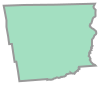

In [ ]:
tessellation['geometry'][0]

Tessellation is a geodataframe containing geometry represented as a GeoSeries.

In [ ]:
type(tessellation)

geopandas.geodataframe.GeoDataFrame

In [ ]:
type(tessellation['geometry'][0])

shapely.geometry.polygon.Polygon

In [ ]:
print(tessellation['geometry'][0].wkt, '\n')
print(tessellation['geometry'][0].boundary, '\n') # represents exterior of the shape, takes same values as wkt
print(tessellation['geometry'][0].area, '\n')
print(tessellation.crs)

POLYGON ((-74.006668 44.886017, -74.027389 44.995685, -73.87459699999999 45.001223, -73.639718 45.003464, -73.343124 45.01084, -73.35463300000001 44.987352, -73.350218 44.976222, -73.338244 44.964751, -73.339603 44.943371, -73.33897899999999 44.917681, -73.341106 44.914632, -73.350652 44.909634, -73.356218 44.904492, -73.360328 44.897236, -73.36910399999999 44.866681, -73.371968 44.862415, -73.379822 44.857038, -73.37954499999999 44.851651, -73.38159 44.849354, -73.380321 44.847173, -73.381336 44.844683, -73.379447 44.843461, -73.379452 44.83801, -73.37534599999999 44.836307, -73.368275 44.828007, -73.353472 44.820386, -73.335044 44.804109, -73.33315399999999 44.788759, -73.335713 44.782086, -73.34708500000001 44.77298, -73.354361 44.755296, -73.365562 44.741786, -73.365977 44.697559, -73.36130799999999 44.694524, -73.365297 44.687548, -73.370142 44.684855, -73.367209 44.678514, -73.371843 44.676957, -73.37101 44.672763, -73.372719 44.668739, -73.369668 44.663478, -73.374577 44.66189, 

In [ ]:
tessellation.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - NAD83
- bounds: (167.65, 14.92, -47.74, 86.46)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

'Jobs' represents the inflows of a census tract (number of workers commuting to the tract for work). 'Pop' represents the outflows of a census tract (number of workers residing in the tract that leave to work in a different tract).

We need a spatial tesselation and a FlowDataFrame to generate the gravity model. The spatial tessellation structure can be found by navigating to <venv_path>/lib/Python3.9/site-packages/skmob/utils/constants

In [ ]:
# Upgrade geopandas from the version installed along skmob  
# %pip install --upgrade geopandas fiona

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.5/27.5 MB 11.1 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 12.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: pyproj
    Found existing installation: pyproj 2.6.1.post1
    Uninstalling pyproj-2.6.1.post1:
      Successfully uninstalled pyproj-2.6.1.post1
  Attempting uninstall: pyogrio━━━━━━━━━━━━━━━━━ 0/3 [pyproj]
    Found existing installation: pyogrio 0.5.10m 0/3 [pyproj]
    Uninstalling pyogrio-0.5.1:━━━━━━━━━━━━━ 0/3 [pyproj]
      Successfully uninstalled pyogrio-0.5.1 0/3 [pyproj]
  Attempting uninstall: geopandas0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pyogrio]
    Found existing installation: geopandas 0.12.2━━━━━━━━━━━━━ 1/3 [pyogrio]
    Uninstalling geopandas-0.12.2:0m━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [pyogrio]
      Successfully uninstalled geopandas-0.12.2━━━━━━━━━━━━━━━ 1/3 [pyogrio]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [geopandas]/3 [geopandas]
ERROR: pip's dependency resolver d

In [40]:
fl_tessellation = gpd.read_file("../data/FL_2021_TRACT.gdb", layer = 'ACS_2021_5YR_TRACT_12_FLORIDA')

In [ ]:
dsets_grouped['FL'].head()

,Id,Jobs,Pop
0,36071014400,25,0
1,12071010305,482,1628
2,12011110402,945,2337
3,12011110403,329,1853
4,12011110404,354,2120


In [41]:
# fl_tessellation.head()
fl_tessellation.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Length',
       'Shape_Area', 'GEOID_Data', 'geometry'],
      dtype='object')

Join fl_tesselation with dsets_grouped['Fl'] based on the tract Id column

In [46]:
fl_tessellation.rename(columns = {'GEOID': 'Id'}, inplace = True)

In [47]:
fl_tessellation.head()

,STATEFP,COUNTYFP,TRACTCE,Id,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Length,Shape_Area,GEOID_Data,geometry
0,12,127,080600,12127080600,806,Census Tract 806,G5020,S,3855836.0,1396648.0,+29.2785973,-081.0550229,0.114930,0.000488,14000US12127080600,"MULTIPOLYGON (((-81.073 29.293, -81.073 29.293..."
1,12,127,082406,12127082406,824.06,Census Tract 824.06,G5020,S,2161378.0,0.0,+29.1526295,-081.0085288,0.062435,0.000200,14000US12127082406,"MULTIPOLYGON (((-81.02 29.154, -81.02 29.155, ..."
2,12,127,081300,12127081300,813,Census Tract 813,G5020,S,1352627.0,1263614.0,+29.2131309,-081.0042522,0.063099,0.000243,14000US12127081300,"MULTIPOLYGON (((-81.015 29.217, -81.015 29.217..."
3,12,127,081500,12127081500,815,Census Tract 815,G5020,S,1159201.0,279283.0,+29.2239763,-081.0256998,0.055922,0.000133,14000US12127081500,"MULTIPOLYGON (((-81.034 29.226, -81.033 29.226..."
4,12,127,081600,12127081600,816,Census Tract 816,G5020,S,1535085.0,0.0,+29.2220958,-081.0403122,0.049670,0.000142,14000US12127081600,"MULTIPOLYGON (((-81.049 29.223, -81.049 29.223..."


In [39]:
type(fl_tessellation['Id'])

pandas.core.series.Series

In [18]:
grouped = pd.DataFrame(set(datasets['FL']['Otract'].unique()).union(set(datasets['FL']['Dtract'].unique())), 
                        columns = ["Id"])
count = 0
for id in grouped["Id"]:
    if id not in fl_tessellation['Id'].values:
        count += 1
print(count)

8256


In [43]:
print(len(grouped), len(fl_tessellation))

8256 5160


Note that the datatype of 'Id' is string in 'tesselation' but 'int' in 'datasets'. To generate the flowTraj data class from skmob, we need them to match exactly. 

In [53]:
count = 0
for id in fl_tessellation['Id'].unique():
    if id in datasets['FL']['Otract'].values or id in datasets['FL']['Dtract'].values:
        count += 1
print(count)

0


In [58]:
print(type(datasets['FL']['Otract'].unique()[0]), type(fl_tessellation['Id'][0]))

<class 'numpy.int64'> <class 'str'>


Also note that the tract ids for the Dtracts in the flows data contain fips state codes (leading digits) that are different than 12, which is the state code for Florida.

In [ ]:
print(min(fl_tessellation['Id']), max(fl_tessellation['Id']))

12133970303 12001000201


In [60]:
print(min(datasets['FL']['Otract'].unique()), max(datasets['FL']['Otract'].unique()))
print(len(str(min(datasets['FL']['Otract'].unique()))), len(str(max(datasets['FL']['Otract'].unique()))))

12001000201 12133970303
11 11


In [61]:
print(min(datasets['FL']['Dtract'].unique()), max(datasets['FL']['Dtract'].unique()))
print(len(str(min(datasets['FL']['Dtract'].unique()))), len(str(max(datasets['FL']['Dtract'].unique()))))

1003010100 56033000400
10 11


In [63]:
Otracts = datasets['FL']['Otract'].unique()
Dtracts = datasets['FL']['Dtract'].unique()

In [66]:
Otracts = Otracts.astype(str)
Dtracts = Dtracts.astype(str)

In [70]:
anamolies = 0
for id in Otracts:
    if not id.startswith('12'):
        anamolies += 1
print(anamolies)
anamolies = 0
for id in Otracts:
    if len(id) != 11:
        anamolies += 1
print(anamolies)

0
0


Using https://tigerweb.geo.census.gov/tigerweb/ and the 2020 census layer we can identify tracts that are not in Florida and their locations. Some dtracts identified were census tracts in Texas, North Carolina, and Kentucky. These values would mean that a commuter originates in Fl (all Otracts have Fl fips) and arrive in a destination tract in Texas, etc. Also, the dtracts with 10 digit geoid should be county subdivisions, however no features were found with the 2020 county subdivision query filters. So, we will view these as tracts formatted incorrectly.  

In [76]:
anamolies = 0
print("Tracts not in Florida:", '\n')
for id in Dtracts:
    if not id.startswith('12'):
        if anamolies < 5:
            print(id, '\n')
        anamolies += 1
print("Total: ", count, '\n')
print("Tracts formatted incorrectly:", '\n')
anamolies = 0
digits = set()
for id in Dtracts:
    if len(id) != 11:
        digits.add(len(id))
        if anamolies < 5:
            print(id, '\n')
        anamolies += 1
print("Total: ", anamolies)


Tracts not in Florida: 

1073002402 

48163950301 

37063002038 

21111003501 

21111011007 

Total:  3155 

Tracts formatted incorrectly: 

1073002402 

4013614700 

9001110202 

6059052439 

1101005904 

Total:  434


In [81]:
for digit in digits:
    print(digit)

10


Clean the dataset to filter out tracts with a fips code other than their state code. Also, ignore tract data that is different than 11 digits.

In [ ]:
fips_data = pd.read_csv("../data/2020_fips.txt", sep = "|")

In [88]:
# type(fips_data)
fips_data.head()

,STATE,STATEFP,STATENS,STATE_NAME
0,AL,1,1779775,Alabama
1,AK,2,1785533,Alaska
2,AZ,4,1779777,Arizona
3,AR,5,68085,Arkansas
4,CA,6,1779778,California


In [103]:
fips_data[fips_data['STATE'] == "FL"]['STATEFP'].values[0]

12

In [112]:
fips_data[fips_data['STATE'] == "FL"]['STATEFP'].index[0]

9

In [127]:
datasets['FL']['Dtract'][0]

12001000201

In [136]:
def clean_data(datasets: dict):
    for state_code, df in datasets.items():
        fips = fips_data[fips_data['STATE'] == state_code]['STATEFP'].values[0]
        df = df[df['Dtract'].startswith(fips)]
        df = df[df['Dtract'].str.len() == 11]
        datasets[state_code] = df
    return datasets

    

In [ ]:
def get_grouped_data():

In [75]:
fl_tessellation['Id'] = fl_tessellation['Id'].astype(str)
dsets_grouped['FL']['Id'] = dsets_grouped['FL']['Id'].astype(str)
# fl_tessellation_merged = fl_tessellation.merge(dsets_grouped['FL'], on='Id')

In [45]:
print(len(datasets['FL']['Otract'].unique()), len(datasets['FL']['Dtract'].unique()))

5075 8253


In [39]:
datasets['FL'].head()

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0
2,12001000201,12001000301,20.0
3,12001000201,12001000400,225.0
4,12001000201,12001000500,35.0


In [21]:
print(min(grouped['Id']), max(grouped['Id']))

1003010100 56033000400


In [22]:
print(min(fl_tessellation['Id']), max(fl_tessellation['Id']))

12001000201 12133970303


In [23]:
print(min(fl_tessellation['TRACTCE']), max(fl_tessellation['TRACTCE']))

000100 990200


In [46]:
fl_tessellation.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'Id', 'NAME', 'NAMELSAD', 'MTFCC',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Length',
       'Shape_Area', 'GEOID_Data', 'geometry', 'Jobs', 'Pop'],
      dtype='object')

In [ ]:
flows_ex = skmob.utils.constants.NY_FLOWS_2011 #https://raw.githubusercontent.com/scikit-mobility/scikit-mobility/master/examples/NY_commuting_flows_2011.csv
flows_ex = pd.read_csv(flows_ex)

In [ ]:
flows_ex.head()

,flow,origin,destination
0,121606,36001,36001
1,5,36001,36005
2,29,36001,36007
3,11,36001,36017
4,30,36001,36019


In [68]:
count = 0
for id in dsets_grouped['FL']['Id']:
    if id in datasets['FL']['Otract'].values:
        count += 1
print(count)

0


In [66]:
print(max(dsets_grouped['FL']['Id']), min(dsets_grouped['FL']['Id']))

9015907100 10003002800


In [67]:
print(max(datasets['FL']['Otract']), min(datasets['FL']['Otract']))

12133970303 12001000201


In [77]:
print(fl_tessellation['Id'].max(), fl_tessellation['Id'].min())

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
datasets['FL'].head()

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0
2,12001000201,12001000301,20.0
3,12001000201,12001000400,225.0
4,12001000201,12001000500,35.0


In [ ]:
# check implementation of grouped datasets and that census tracts are same as in datasets origin, dest
fdf = skmob.FlowDataFrame(datasets['FL'],
                            origin = 'Otract',
                            destination = 'Dtract',
                            flow = 'EST',
                            tile_id='Id',
                            tessellation= fl_tessellation)

ValueError: Inconsistency - origin and destination IDs must be present in the tessellation.